In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import load_iris

## Preprocessing


In [3]:
iris = load_iris()

In [4]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [5]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [8]:
df.drop(["sepal length (cm)", "sepal width (cm)"], axis=1, inplace=True)

In [9]:
scalar = MinMaxScaler()
df[["petal length (cm)", "petal width (cm)"]] = scalar.fit_transform(df[["petal length (cm)", "petal width (cm)"]])

In [10]:
df.head(5)

,petal length (cm),petal width (cm),target
0,0.067797,0.041667,0
1,0.067797,0.041667,0
2,0.050847,0.041667,0
3,0.084746,0.041667,0
4,0.067797,0.041667,0


## K Means Clustering

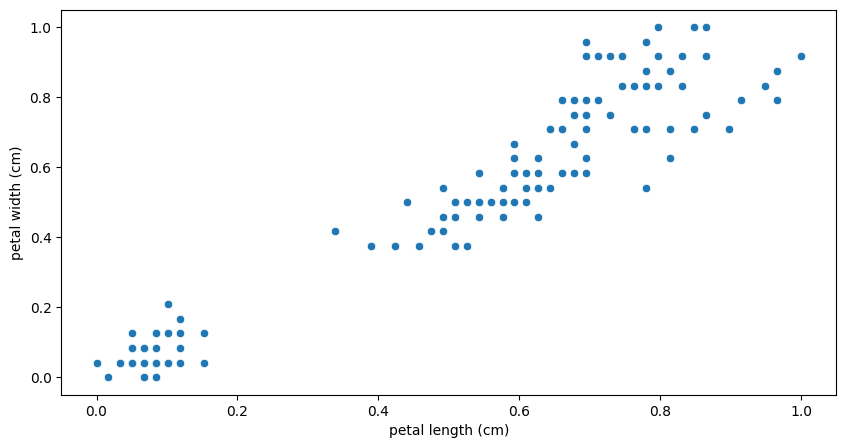

In [11]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)")
plt.show()

In [12]:
sse = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[["petal length (cm)", "petal width (cm)"]])
    sse.append(kmeans.inertia_)

## Elbow method


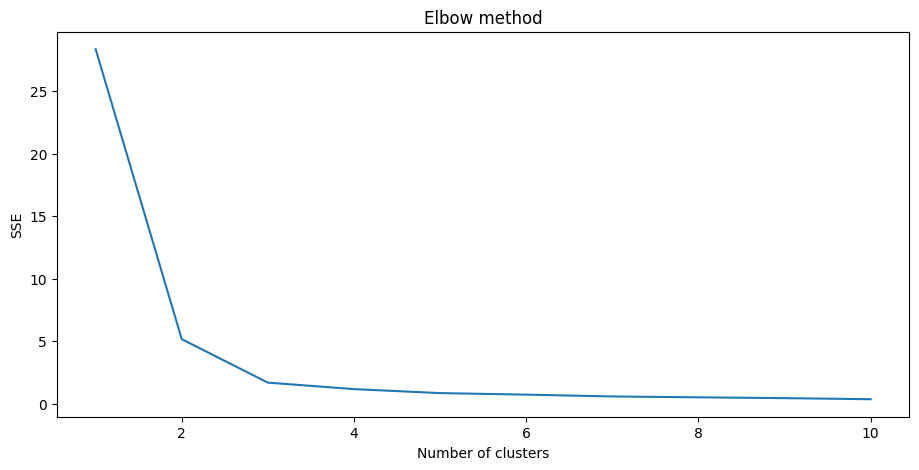

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(range(1, 11), sse)
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("SSE")
plt.show()

In [15]:
df["Predict"] = KMeans(n_clusters=3).fit_predict(df[["petal length (cm)", "petal width (cm)"]])

In [17]:
df.head()

,petal length (cm),petal width (cm),target,Predict
0,0.067797,0.041667,0,0
1,0.067797,0.041667,0,0
2,0.050847,0.041667,0,0
3,0.084746,0.041667,0,0
4,0.067797,0.041667,0,0


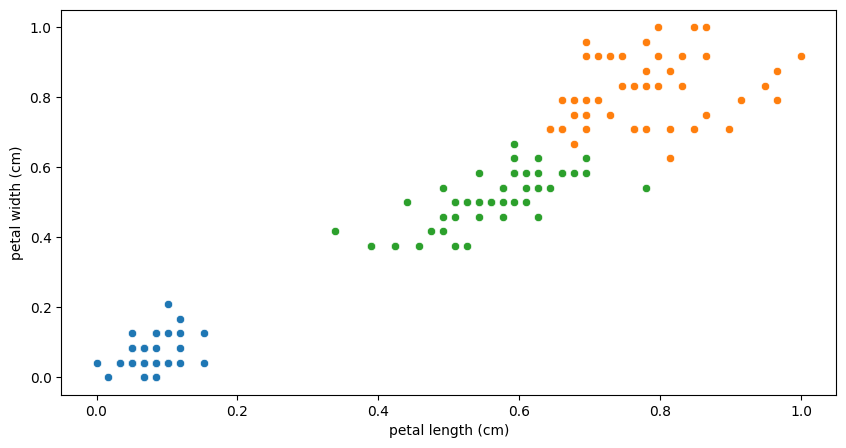

In [18]:
plt.figure(figsize=(10, 5))
df1 = df[df["Predict"] == 0]
df2 = df[df["Predict"] == 1]
df3 = df[df["Predict"] == 2]

sns.scatterplot(data=df1, x="petal length (cm)", y="petal width (cm)")
sns.scatterplot(data=df2, x="petal length (cm)", y="petal width (cm)")
sns.scatterplot(data=df3, x="petal length (cm)", y="petal width (cm)")

plt.show()